In [59]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


from dotenv import load_dotenv
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field



from langgraph.graph import StateGraph,START,END

load_dotenv()

True

# 1. Quadratic Equation Solver

In [2]:

class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str
    
graph=StateGraph(state_schema=QuadState)

In [3]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation':equation}

def calculate_discriminant(state: QuadState):

    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant': discriminant}

def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [4]:
graph.add_node('show_equation',show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(start_key=START,end_key='show_equation')
graph.add_edge(start_key='show_equation',end_key='calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition,{'real_roots':"real_roots",'repeated_roots':'repeated_roots','no_real_roots':'no_real_roots'})

graph.add_edge(start_key='real_roots',end_key=END)
graph.add_edge(start_key='repeated_roots',end_key=END)
graph.add_edge(start_key='no_real_roots',end_key=END)

In [5]:
workflow=graph.compile()

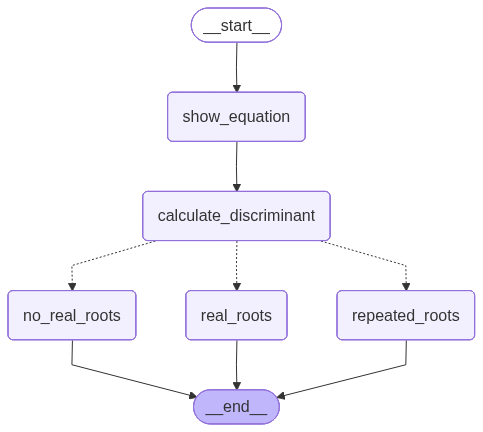

In [6]:
workflow

In [7]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}

# 2. Review Sentiment Analysis

In [91]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['Positive','Negative']
    positive_review:str
    review_analysis:str
    priority:Literal['High','Medium','Low']
    Type:Literal['Product','Billing','CustomerSupport','Other']
    negative_review:str

In [92]:
class SentimentStructure(BaseModel):
    sentiment:Literal['Positive','Negative']=Field(description='For the attached review please find its sentiment')
    
    
class AnalyzerStructure(BaseModel):
    review_analysis:str=Field(description='generate a indepth review of the attached uses feedback.')
    priority:Literal['High','Medium','Low']=Field(description='find the priority of the review to be resolved')
    Type:Literal['Product','Billing','CustomerSupport','Other']=Field(description='find the type of the review')

In [93]:
sentiment_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite').with_structured_output(schema=SentimentStructure)
positive_response_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
negative_response_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
analysis_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite').with_structured_output(schema=AnalyzerStructure)

In [94]:
parser=StrOutputParser()

In [95]:
def sentiment_analyzer(state: ReviewState):
    review=state['review']
    
    prompt=PromptTemplate(
        template='''
        
            For the attached review please find its sentiment in either Positive or Negative only
            review: {review}
        
        
        ''',
        input_variables=['review']
    )
    
    chain=prompt | sentiment_model
    
    response=chain.invoke({'review':review})
    
    return {'sentiment':response.sentiment}



def check_sentiment(state: ReviewState)-> Literal['Positive','Negative']:
    sentiment=state['sentiment']
    
    if sentiment=='Positive':
        return 'Positive'
    else:
        return 'Negative'
    
def generate_analysis(state: ReviewState):
    review=state['review']
    
    prompt=PromptTemplate(
        template='''
        
            For the attached review please generate a detailed analysis. what the issue is. what user did not like. which type of issue it is. priority of the resolution..etc
            review: {review}
        ''',
        input_variables=['review']
    )
    
    chain=prompt | analysis_model
    
    response=chain.invoke({'review':review})
    
    return {'review_analysis':response.review_analysis,'priority':response.priority,'Type':response.Type}

def negative_response_generator(state: ReviewState):
    review_analysis=state['review_analysis']
    Type=state['Type']
    priority=state['priority']
    
    prompt=PromptTemplate(
        template='''
        
            You are a professional customer support assistant.

            Task:
            Generate a formal and empathetic response to a customer review reporting an issue.

            Guidelines:
            - Acknowledge that the review has been received
            - Apologize sincerely for the inconvenience caused
            - Mention that the issue has been categorized and prioritized
            - Include the issue type and priority naturally in the response
            - Maintain a calm, respectful, and professional tone
            - Reassure the user that the issue is being addressed
            - Keep the response concise (4–6 sentences)
            - Do NOT blame the user or make unrealistic promises

            Review:
            {review}

            Issue Type:
            {Type}

            Priority Level:
            {priority}

            Output:
            A clean, professional response message.
        ''',
        input_variables=['review','Type','priority']
    )
    
    chain=prompt | negative_response_model | parser
    
    response=chain.invoke({'review':review_analysis,'Type':Type,'priority':priority})
    return {'negative_review':response}

def positive_response_generator(state: ReviewState):
    review=state['review']
    
    prompt=PromptTemplate(
        template='''
        
            You are a professional customer support assistant.

            Task:
            Generate a formal, warm, and enthusiastic response to a customer review.

            Guidelines:
            - Thank the user for using our product
            - Express genuine happiness that they liked the product
            - Maintain a professional and positive tone
            - Keep the message concise (3–5 sentences)
            - Do NOT repeat the review verbatim
            - Do NOT add assumptions beyond the review
            - Use clear and polished language

            Review:
            {review}

            Output:
            A well-structured response message.

        ''',
        input_variables=['review']
    )
    
    chain=prompt | positive_response_model | parser
    
    response=chain.invoke({'review':review})
    return {'positive_review':response}

In [96]:
graph=StateGraph(state_schema=ReviewState)

graph.add_node('sentiment_analyzer',sentiment_analyzer)
graph.add_node('generate_analysis',generate_analysis)
graph.add_node('negative_response_generator',negative_response_generator)
graph.add_node('positive_response_generator',positive_response_generator)

graph.add_edge(start_key=START,end_key='sentiment_analyzer')

graph.add_conditional_edges(
    source='sentiment_analyzer',
    path=check_sentiment,
    path_map={
        'Negative': 'generate_analysis',
        'Positive': 'positive_response_generator'
    }
)
graph.add_edge(start_key='generate_analysis',end_key='negative_response_generator')
graph.add_edge(start_key='negative_response_generator',end_key=END)
graph.add_edge(start_key='positive_response_generator',end_key=END)

workflow=graph.compile()

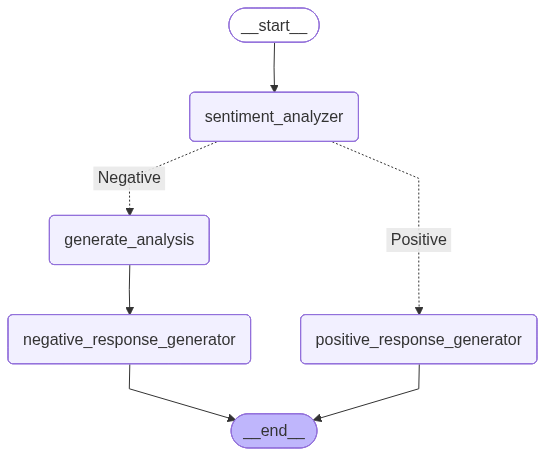

In [97]:
workflow

In [98]:
pos_review='''

I’ve been using this product for a few weeks now and I’m really impressed. The interface is clean, easy to use, and everything works smoothly. It has definitely improved my productivity. Great job by the team!

'''

neg_review='''

I’m quite disappointed with this product. It crashes frequently and some features don’t work as expected. It’s been frustrating to use and needs improvement.

'''

In [99]:
response=workflow.invoke({'review':pos_review})

In [100]:
response

{'review': '\n\nI’ve been using this product for a few weeks now and I’m really impressed. The interface is clean, easy to use, and everything works smoothly. It has definitely improved my productivity. Great job by the team!\n\n',
 'sentiment': 'Positive',
 'positive_review': "Thank you so much for taking the time to share your positive experience with our product! We're absolutely thrilled to hear that you've found it impressive and that it has significantly boosted your productivity. It's wonderful to know that our focus on a clean, user-friendly interface and smooth functionality has resonated so well with you. We truly appreciate your kind words about our team's efforts!"}

In [102]:
response=workflow.invoke({'review':neg_review})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 45.173566627s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM

In [ ]:
response